# Lab 5 — Orbital Mechanics Simulator

**Name:** Matthew Nallar  
**Date:** September 27, 2026

In [1]:
import numpy as np
import matplotlib.pyplot as plt

***Part A***

In [2]:
G, M = 1.0, 1.0       # star at origin

def verlet_step(r, v, a, dt, accel_func):
    """One Velocity Verlet step. accel_func(r) returns acceleration at position r."""
    r_new = r + v * dt + 0.5 * a * dt**2
    a_new = accel_func(r_new)
    v_new = v + 0.5 * (a + a_new) * dt

    return r_new, v_new, a_new

def accel(r):
    dist = np.linalg.norm(r)

    return -G * M * r / dist**3

# Initial conditions for a bound elliptical orbit
r = np.array([1.0, 0.0])
v = np.array([0.0, 0.8])   # less than circular speed (=1.0) -> ellipse
a = accel(r)

dt = 0.001
rs = [r.copy()]
for _ in range(20000):
    r, v, a = verlet_step(r, v, a, dt, accel)
    rs.append(r.copy())
rs = np.array(rs)

def energy(r, v, G=1.0, M=1.0, m=1.0):
    
    ke = 0.5 * m * np.dot(v, v)
    pe = -G * M * m / np.linalg.norm(r)

    return ke + pe

def ang_momentum(r, v, m=1.0):
    # 2D cross product r x v is a scalar

    return m * (r[0] * v[1] - r[1] * v[0])



Initial position: [0.98157566 0.15259203]
Initial velocity: [0.  0.8]
Initial energy: -0.6799999998678659
Final energy: -0.6799999994836281
Initial angular momentum: 0.7999999999999967
Final angular momentum: 0.799999999999996


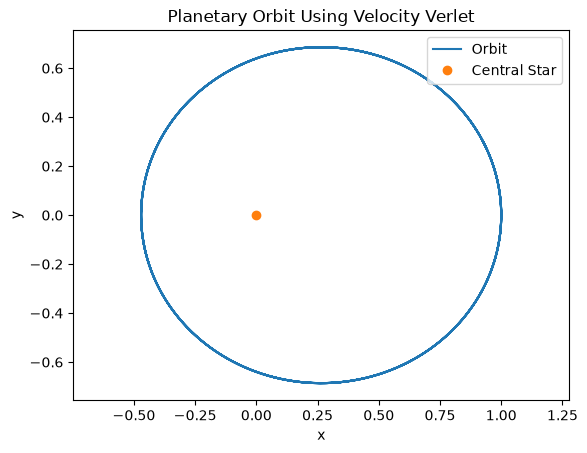

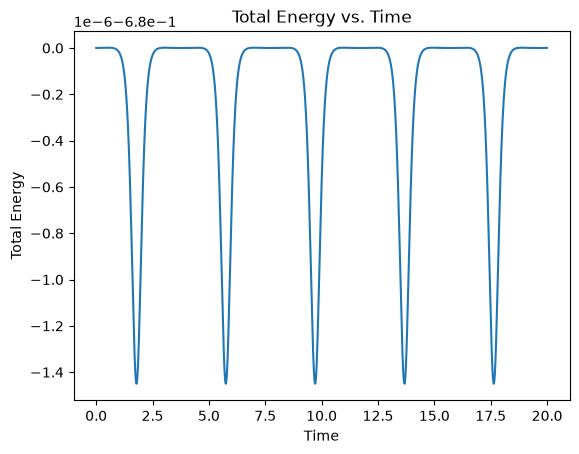

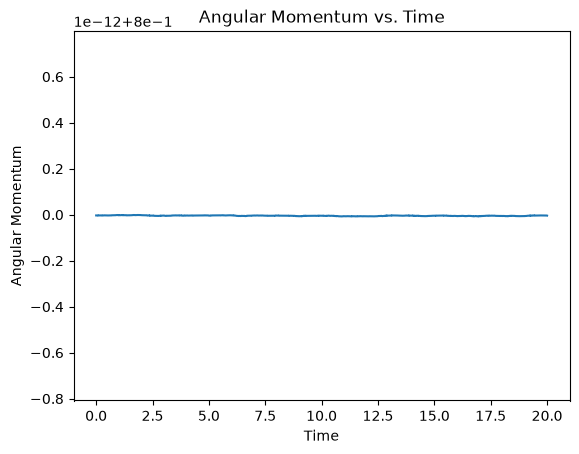

In [3]:
# Calculate initial acceleration
a = accel(r)


# Simulation settings
dt = 0.001
steps = 20000



# Arrays for storing results
times = np.zeros(steps + 1)
positions = np.zeros((steps + 1, 2))
energies = np.zeros(steps + 1)
angular_momenta = np.zeros(steps + 1)


# Store initial values
positions[0] = r
energies[0] = energy(r, v)
angular_momenta[0] = ang_momentum(r, v)



# Run simulation
for i in range(steps):

    # Perform one Velocity Verlet step
    r, v, a = verlet_step(r, v, a, dt, accel)

    # Store time
    times[i + 1] = (i + 1) * dt

    # Store position
    positions[i + 1] = r

    # Store energy
    energies[i + 1] = energy(r, v)

    # Store angular momentum
    angular_momenta[i + 1] = ang_momentum(r, v)


# ============================================================
# Print some basic results
# ============================================================

print("Initial position:", positions[0])
print("Initial velocity:", np.array([0.0, 0.8]))

print("Initial energy:", energies[0])
print("Final energy:", energies[-1])

print("Initial angular momentum:", angular_momenta[0])
print("Final angular momentum:", angular_momenta[-1])



# Plot 1: Orbit trajectory
plt.figure()

plt.plot(
    positions[:, 0],
    positions[:, 1],
    label="Orbit"
)

plt.plot(
    0,
    0,
    "o",
    label="Central Star"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Planetary Orbit Using Velocity Verlet")

plt.axis("equal")

plt.legend(loc="upper right")

plt.show()



# Plot 2: Total energy vs time
plt.figure()

plt.plot(
    times,
    energies
)

plt.xlabel("Time")
plt.ylabel("Total Energy")

plt.title("Total Energy vs. Time")

plt.show()



# Plot 3: Angular momentum vs time
plt.figure()

plt.plot(
    times,
    angular_momenta
)

plt.xlabel("Time")
plt.ylabel("Angular Momentum")

plt.title("Angular Momentum vs. Time")

plt.show()

**Is your starting point periapsis or apoapsis?  How do you know from v0 = 0.8 compared to the circular speed of 1.0?**

The starting point is apoapsis (the highest point in the orbit, where the object moves the slowest). 

You know this because the initial velocity v0 = 0.8 is less than the circular orbit speed vc = 1.0. 

***Part B***

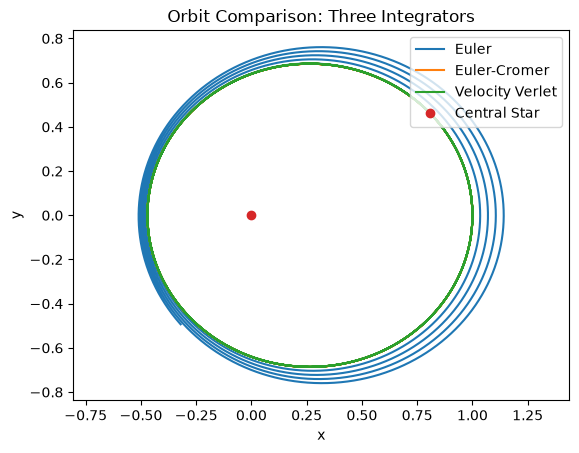

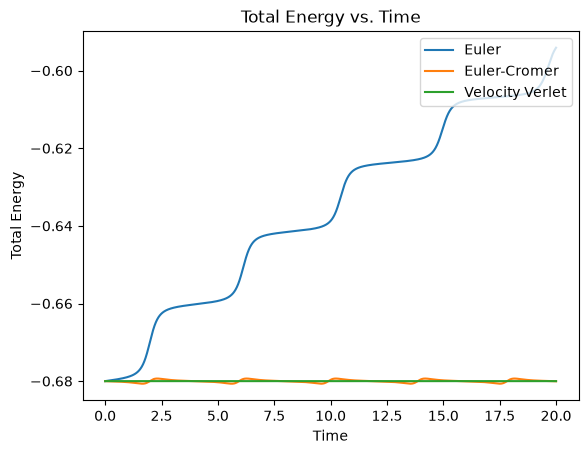

    Method:       	Error:
|Euler         | 0.12633503255338938    |
|Euler-Cromer  | 0.0009763462163022773  |
|Verlet        | 2.1318638648521885e-06 |


In [4]:
def simulate(method, dt, n_steps):

    # --------------------------------------------------------
    # Identical initial conditions for every method
    # --------------------------------------------------------

    r = np.array([1.0, 0.0])
    v = np.array([0.0, 0.8])

    # Initial acceleration
    a = accel(r)

    # --------------------------------------------------------
    # Arrays for storing results
    # --------------------------------------------------------

    times = np.zeros(n_steps + 1)

    positions = np.zeros((n_steps + 1, 2))

    energies = np.zeros(n_steps + 1)

    # --------------------------------------------------------
    # Store initial values
    # --------------------------------------------------------

    positions[0] = r
    energies[0] = energy(r, v)

    # --------------------------------------------------------
    # Run simulation
    # --------------------------------------------------------

    for i in range(n_steps):

        # ================================================
        # Euler
        # ================================================

        if method == "euler":

            # Use current velocity to update position
            r = r + v * dt

            # Use current acceleration to update velocity
            v = v + a * dt

            # Calculate new acceleration
            a = accel(r)

        # ================================================
        # Euler-Cromer
        # ================================================

        elif method == "euler-cromer":

            # Update velocity first
            v = v + a * dt

            # Use NEW velocity to update position
            r = r + v * dt

            # Calculate new acceleration
            a = accel(r)

        # ================================================
        # Velocity Verlet
        # ================================================

        elif method == "verlet":

            r, v, a = verlet_step(r, v, a, dt, accel)

        # ================================================
        # Invalid method
        # ================================================

        else:
            raise ValueError(
                "method must be 'euler', 'euler-cromer', or 'verlet'"
            )

        # ------------------------------------------------
        # Store results
        # ------------------------------------------------

        times[i + 1] = (i + 1) * dt

        positions[i + 1] = r

        energies[i + 1] = energy(r, v)

    return times, positions, energies


# ============================================================
# Simulation settings
# ============================================================

dt = 0.001

n_steps = 20000


# ============================================================
# Run all three methods
# ============================================================

t_euler, r_euler, E_euler = simulate(
    "euler",
    dt,
    n_steps
)

t_ec, r_ec, E_ec = simulate(
    "euler-cromer",
    dt,
    n_steps
)

t_verlet, r_verlet, E_verlet = simulate(
    "verlet",
    dt,
    n_steps
)


# ============================================================
# Plot 1: Compare trajectories
# ============================================================

plt.figure()

plt.plot(
    r_euler[:, 0],
    r_euler[:, 1],
    label="Euler"
)

plt.plot(
    r_ec[:, 0],
    r_ec[:, 1],
    label="Euler-Cromer"
)

plt.plot(
    r_verlet[:, 0],
    r_verlet[:, 1],
    label="Velocity Verlet"
)

# Central star
plt.plot(
    0,
    0,
    "o",
    label="Central Star"
)

plt.xlabel("x")
plt.ylabel("y")

plt.title("Orbit Comparison: Three Integrators")

plt.axis("equal")

plt.legend(loc="upper right")

plt.show()


# ============================================================
# Plot 2: Total energy
# ============================================================

plt.figure()

plt.plot(
    t_euler,
    E_euler,
    label="Euler"
)

plt.plot(
    t_ec,
    E_ec,
    label="Euler-Cromer"
)

plt.plot(
    t_verlet,
    E_verlet,
    label="Velocity Verlet"
)

plt.xlabel("Time")
plt.ylabel("Total Energy")

plt.title("Total Energy vs. Time")

plt.legend(loc="upper right")

plt.show()


# ============================================================
# Calculate fractional energy error
# ============================================================

E0_euler = E_euler[0]
E0_ec = E_ec[0]
E0_verlet = E_verlet[0]

fractional_error_euler = np.abs(
    (E_euler - E0_euler) / E0_euler
)

fractional_error_ec = np.abs(
    (E_ec - E0_ec) / E0_ec
)

fractional_error_verlet = np.abs(
    (E_verlet - E0_verlet) / E0_verlet
)


# ============================================================
# Maximum fractional energy error
# ============================================================

max_error_euler = np.max(fractional_error_euler)

max_error_ec = np.max(fractional_error_ec)

max_error_verlet = np.max(fractional_error_verlet)


# Print errors
print("    Method:       \tError:")
print("|Euler         |", max_error_euler,"   |")
print("|Euler-Cromer  |", max_error_ec," |")
print("|Verlet        |", max_error_verlet,"|")

**Why does Euler gain energy and spiral outward?  Why is Verlet stable even though it's only second-order accurate?  Connect this to the word "symplectic."**

Euler gains energy and spirals outward because its numerical updates do not preserve the geometric structure of the orbital dynamics. Small errors accumulate from each step, causing the total mechanical energy to increase and the orbit to expand. 

Verlet is second-order accurate, as opposed to the first-order Euler method, but its stability comes from being symplectic. A symplectic integrator preserves the underlying phase-space structure of Hamiltonian mechanics, so its energy error tends to remain bounded and oscillate around the true value rather than continuously drift. As a result, Verlet can maintain a stable orbital trajectory over many periods even though it is only second-order accurate.

***Part C***

FIRST LAW
Minimum distance = 0.47058912735583197
Maximum distance = 1.0
Estimated semi-major axis = 0.735294563677916


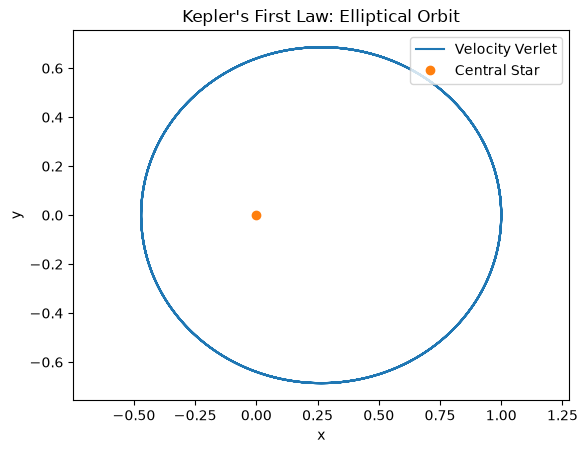

SECOND LAW
Mean swept area per step = 4.00000000e-04
Standard deviation        = 1.07281253e-18


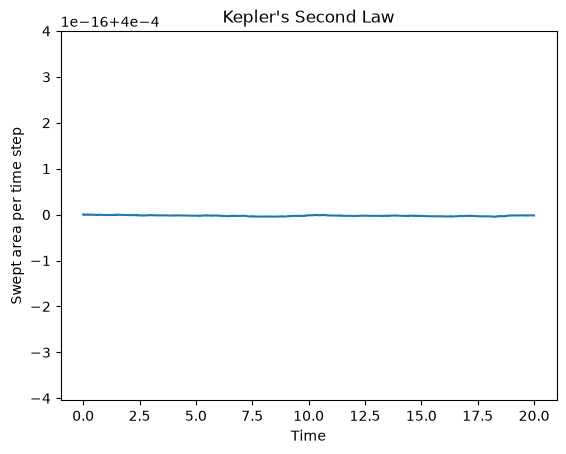


THIRD LAW
v0 = 0.6, a = 0.60976, T = 2.99200
v0 = 0.7, a = 0.66225, T = 3.38600
v0 = 0.8, a = 0.73529, T = 3.96100
v0 = 0.9, a = 0.84034, T = 4.84000
Measured slope = 39.47400844858643
Theoretical slope = 39.47841760435743
Percent difference = 0.011168522039530194 %


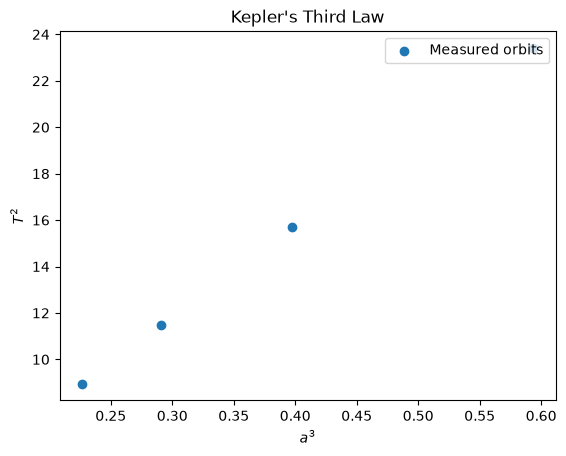

In [5]:
# ============================================================
# 1. Orbits are ellipses with the star at one focus
# ============================================================

# Run one orbit using Velocity Verlet
dt = 0.001
n_steps = 20000

times, positions, energies = simulate(
    "verlet",
    dt,
    n_steps
)

# Distance from the central star at every time step
distances = np.linalg.norm(positions, axis=1)

# Minimum and maximum distance
r_min = np.min(distances)
r_max = np.max(distances)

# Estimate semi-major axis
a = (r_min + r_max) / 2

print("FIRST LAW")
print("Minimum distance =", r_min)
print("Maximum distance =", r_max)
print("Estimated semi-major axis =", a)


# Plot the orbit
plt.figure()

plt.plot(
    positions[:, 0],
    positions[:, 1],
    label="Velocity Verlet"
)

plt.plot(
    0,
    0,
    "o",
    label="Central Star"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Kepler's First Law: Elliptical Orbit")

plt.axis("equal")
plt.legend(loc="upper right")

plt.show()


# ============================================================
# 2. Second Law — Equal areas swept in equal times
# ============================================================

# Initial conditions
r = np.array([1.0, 0.0])
v = np.array([0.0, 0.8])
a_accel = accel(r)

n_steps = 20000

times = np.zeros(n_steps + 1)
positions = np.zeros((n_steps + 1, 2))
velocities = np.zeros((n_steps + 1, 2))
areas = np.zeros(n_steps + 1)

positions[0] = r
velocities[0] = v

for i in range(n_steps):
    r, v, a_accel = verlet_step(
        r, v, a_accel, dt, accel
    )

    times[i + 1] = (i + 1) * dt
    positions[i + 1] = r
    velocities[i + 1] = v

# Calculate swept area per time step
for i in range(n_steps + 1):
    x, y = positions[i]
    vx, vy = velocities[i]

    cross_product = x * vy - y * vx

    areas[i] = 0.5 * abs(cross_product) * dt

# Plot swept area per step
print("SECOND LAW")
print(f"Mean swept area per step = {np.mean(areas):.8e}")
print(f"Standard deviation        = {np.std(areas):.8e}")

plt.figure()
plt.plot(times, areas)

plt.xlabel("Time")
plt.ylabel("Swept area per time step")
plt.title("Kepler's Second Law")
plt.show()


# ============================================================
# 3. Third Law — T² ∝ a³
# ============================================================
print("\nTHIRD LAW")
# Initial velocities for four different elliptical orbits
v0_values = [0.6, 0.7, 0.8, 0.9]

# Arrays for storing results
semi_major_axes = []
periods = []


# ------------------------------------------------------------
# Run each orbit
# ------------------------------------------------------------

for v0 in v0_values:

    # Initial conditions
    r = np.array([1.0, 0.0])
    v = np.array([0.0, v0])
    a_accel = accel(r)

    # Initial energy
    E0 = energy(r, v)

    # Calculate theoretical semi-major axis
    # E = -GM/(2a)
    semi_major_axis_theory = -G * M / (2 * E0)

    # Estimate orbital period from Kepler's third law
    period_estimate = 2 * np.pi * semi_major_axis_theory**1.5

    # Simulate for several periods
    dt_orbit = 0.001

    n_steps_orbit = int(2 * period_estimate / dt_orbit)

    positions_orbit = np.zeros((n_steps_orbit + 1, 2))
    times_orbit = np.zeros(n_steps_orbit + 1)

    positions_orbit[0] = r

    # Run simulation manually
    for i in range(n_steps_orbit):

        r, v, a_accel = verlet_step(
            r,
            v,
            a_accel,
            dt_orbit,
            accel
        )

        positions_orbit[i + 1] = r
        times_orbit[i + 1] = (i + 1) * dt_orbit

    # Calculate distances
    distances_orbit = np.linalg.norm(
        positions_orbit,
        axis=1
    )

    # Estimate semi-major axis from trajectory
    r_min = np.min(distances_orbit)
    r_max = np.max(distances_orbit)

    a_measured = (r_min + r_max) / 2

    # --------------------------------------------------------
    # Measure period using repeated periapsis
    # --------------------------------------------------------

    # Find local minima in distance
    periapsis_indices = []

    for i in range(1, len(distances_orbit) - 1):

        if (
            distances_orbit[i] < distances_orbit[i - 1]
            and
            distances_orbit[i] < distances_orbit[i + 1]
        ):
            periapsis_indices.append(i)

    # Need at least two periapsis points to measure a period
    if len(periapsis_indices) >= 2:

        periods_found = np.diff(
            times_orbit[periapsis_indices]
        )

        T_measured = np.mean(periods_found)

    else:

        T_measured = np.nan

    semi_major_axes.append(a_measured)
    periods.append(T_measured)

    print(
        f"v0 = {v0:.1f}, "
        f"a = {a_measured:.5f}, "
        f"T = {T_measured:.5f}"
    )


# Convert to NumPy arrays
semi_major_axes = np.array(semi_major_axes)
periods = np.array(periods)

# Calculate a^3 and T^2
a_cubed = semi_major_axes**3
T_squared = periods**2


# ============================================================
# Calculate measured slope
# ============================================================

# Fit a line through the origin:
# T^2 = slope * a^3

slope = np.sum(a_cubed * T_squared) / np.sum(a_cubed**2)

# Theoretical slope
theoretical_slope = 4 * np.pi**2 / (G * M)

print("Measured slope =", slope)

print("Theoretical slope =", theoretical_slope)

print(
    "Percent difference =",
    abs(slope - theoretical_slope)
    / theoretical_slope * 100,
    "%"
)

# ============================================================
# Plot T^2 vs a^3
# ============================================================

plt.figure()

plt.scatter(
    a_cubed,
    T_squared,
    label="Measured orbits"
)

plt.xlabel("$a^3$")
plt.ylabel("$T^2$")

plt.title("Kepler's Third Law")

plt.legend(loc="upper right")

plt.show()

 **How well do your measured slopes match theory? What's your main source of error, step size, period-measurement resolution, or semi-major-axis estimation?**

 The measured relationship between "T^2" and "a^3" was approximately linear and passed close to the origin, confirming Kepler's third law. The measured slope was ~39.474, compared with the theoretical value 4*pi^2/(GM)=39.4784, where G=M=1. 
 
 The difference is due to numerical resolution in measuring the orbital period and estimating the semi-major axis from the minimum and maximum orbital radii. The timestep of dt=0.001 is small, so the timestep error is expected to be relatively small compared with the uncertainty in identifying the exact periapsis time and estimating "a".